# Inverse PINN for simultaneous identification of displacement and a spatially varying Young's modulus

The goal is to identify both the displacement $u(x)$ and an unknown nonconstant Young's modulus $E(x)$ of a one-dimensional elastic bar on

$$
\Omega=(0,1).
$$

For a synthetic inverse experiment, the exact displacement is

$$
u_{\mathrm{exact}}(x)=a\sin(2\pi x),
\qquad
0<a<\frac{1}{2\pi}.
$$

The spatially varying Young's modulus is fixed as

$$
E_{\mathrm{true}}(x)=1+0.5x.
$$

The strain and stress are

$$
\varepsilon(x)=u'(x),
\qquad
\sigma(x)=E(x)u'(x),
$$

and equilibrium requires

$$
\frac{\mathrm d}{\mathrm dx}
\left(E(x)u'(x)\right)+b(x)=0.
$$

The corresponding known body force is

$$
b_{\mathrm{known}}(x)
=4\pi^2a(1+0.5x)\sin(2\pi x)
-\pi a\cos(2\pi x).
$$

The PINN learns $u_\theta(x)$ and $E_\theta(x)$ as two outputs of one shared network from the equilibrium equation and sparse displacement observations.

## 1. Library imports

In [61]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
torch.set_default_dtype(torch.float64)

## 2. Parameters

Set `USE_NOISY_DATA = False` to use exact sparse observations. Set it to `True` to add independent zero-mean Gaussian measurement noise:

$$
u_i^{\mathrm{obs}}
=u_{\mathrm{exact}}(x_i)+\eta_i,
\qquad
\eta_i\sim\mathcal N(0,s_{\mathrm{noise}}^2).
$$



In [62]:
USE_NOISY_DATA = True
NOISE_RELATIVE_STD = 0.02
L = 1.0
INITIAL_E = 0.8
AMPLITUDE = 0.05
N_PDE_TRAIN = 1000
N_PDE_VALIDATION = 100
N_PDE_TEST = 1000
PDE_BATCH_SIZE = 16
N_REGULARIZATION = 200
N_DATA_TOTAL = 72
N_DATA_TRAIN = 50
N_DATA_VALIDATION = 11
N_DATA_TEST = N_DATA_TOTAL - N_DATA_TRAIN - N_DATA_VALIDATION
EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 0.003
SEED = 42
WEIGHT_PDE = 1.0
WEIGHT_DATA = 100.0
WEIGHT_REGULARIZATION = 1e-9
WEIGHT_VALIDATION_PDE = WEIGHT_PDE
WEIGHT_VALIDATION_DATA = WEIGHT_DATA
NOISE_STD = NOISE_RELATIVE_STD * AMPLITUDE
torch.manual_seed(SEED)


## 3. Exact fields for synthetic data and evaluation

In [63]:
def exact_solution(x):
    """Exact displacement used to generate synthetic observations."""
    return AMPLITUDE * torch.sin(2.0 * torch.pi * x)

def exact_strain(x):
    """Exact strain u'(x)."""
    return 2.0 * torch.pi * AMPLITUDE * torch.cos(2.0 * torch.pi * x)

def exact_young_modulus(x):
    """Spatially varying Young modulus used for the benchmark."""
    return 1.0 + 0.5 * x * torch.cos(torch.pi * x)

def exact_stress(x):
    """Exact stress E(x)u'(x)."""
    return exact_young_modulus(x) * exact_strain(x)

def known_body_force(x):
    young_modulus = exact_young_modulus(x)
    dE_dx = (
        0.5 * torch.cos(torch.pi * x)
        - 0.5 * torch.pi * x * torch.sin(torch.pi * x)
    )

    return (
        4.0 * torch.pi**2 * AMPLITUDE
        * young_modulus * torch.sin(2.0 * torch.pi * x)
        - 2.0 * torch.pi * AMPLITUDE
        * dE_dx * torch.cos(2.0 * torch.pi * x)
    )

## 4. One neural network for displacement and Young's modulus

One shared neural network with two outputs approximates

$$
u(x)\approx u_\theta(x),
\qquad
E(x)\approx E_\theta(x).
$$

The output vector is $[u_\theta(x),E_\theta(x)]^{\mathsf T}$. The second output is initialized close to `INITIAL_E`, but it remains an unconstrained trainable function.

In [64]:
class InverseVariableModulusPINN(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 30),
            nn.Tanh(), 
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(), 
            nn.Linear(30, 2)
            )
        
        with torch.no_grad():
            self.net[-1].bias[0] = 0.0
            self.net[-1].bias[1] = INITIAL_E

    def forward(self, x):
        return self.net(x)

    def displacement(self, x):
        return self.forward(x)[:, 0:1]

    def young_modulus(self, x):
        return self.forward(x)[:, 1:2]
model = InverseVariableModulusPINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)

## 5. Training, validation, and test collocation points

Training collocation points are used by the optimizers. A separate fixed set of 1000 validation collocation points contributes only to checkpoint selection. Independent test points remain unused until the final evaluation.


In [65]:
pde_train_generator = torch.Generator().manual_seed(SEED + 1)
x_pde_train = L * torch.rand(N_PDE_TRAIN, 1, generator=pde_train_generator)
pde_dataset = TensorDataset(x_pde_train)
pde_batch_generator = torch.Generator().manual_seed(SEED + 2)
pde_loader = DataLoader(pde_dataset, batch_size=PDE_BATCH_SIZE, shuffle=True, generator=pde_batch_generator)

pde_validation_generator = torch.Generator().manual_seed(SEED + 3)
x_pde_validation = L * torch.rand(N_PDE_VALIDATION, 1, generator=pde_validation_generator)
x_pde_validation, _ = torch.sort(x_pde_validation, dim=0)

pde_test_generator = torch.Generator().manual_seed(SEED + 4)
x_pde_test = L * torch.rand(N_PDE_TEST, 1, generator=pde_test_generator)
x_pde_test, _ = torch.sort(x_pde_test, dim=0)


# Midpoints of the rectangles used for the regularization integral.
REGULARIZATION_DX = L / N_REGULARIZATION
x_regularization = (torch.arange(N_REGULARIZATION).view(-1, 1) + 0.5) * REGULARIZATION_DX


## 6. Train/validation/test split of sparse displacement observations

Only training observations update the network parameters. Validation observations contribute to the checkpoint score, and test observations remain unused until the final evaluation.


In [66]:
x_data_all = torch.linspace(0.0, L, N_DATA_TOTAL).view(-1, 1)
split_generator = torch.Generator().manual_seed(SEED + 6)
permutation = torch.randperm(N_DATA_TOTAL, generator=split_generator)
train_end = N_DATA_TRAIN
validation_end = N_DATA_TRAIN + N_DATA_VALIDATION
train_indices = permutation[:train_end]
validation_indices = permutation[train_end:validation_end]
test_indices = permutation[validation_end:]

u_data_all_clean = exact_solution(x_data_all).detach()
u_data_all_observed = u_data_all_clean.clone()
if USE_NOISY_DATA:
    noise_generator = torch.Generator().manual_seed(SEED + 7)
    u_data_all_observed += NOISE_STD * torch.randn(u_data_all_observed.shape, generator=noise_generator)

x_data_train = x_data_all[train_indices]
u_data_train = u_data_all_observed[train_indices]
u_data_train_clean = u_data_all_clean[train_indices]
x_data_validation = x_data_all[validation_indices]
u_data_validation = u_data_all_observed[validation_indices]
u_data_validation_clean = u_data_all_clean[validation_indices]
x_data_test = x_data_all[test_indices]
u_data_test = u_data_all_observed[test_indices]
u_data_test_clean = u_data_all_clean[test_indices]
print(f'Sparse data split: {N_DATA_TRAIN} train, {N_DATA_VALIDATION} validation, {N_DATA_TEST} test')


Sparse data split: 50 train, 11 validation, 11 test


## 7. PDE residual, modulus regularization, and losses

For the spatially varying modulus,

$$
r_{\mathrm{PDE},\theta}(x)=\frac{\mathrm d}{\mathrm dx}\left(E_\theta(x)u_\theta'(x)\right)+b_{\mathrm{known}}(x).
$$

The training loss includes the PDE residual, training displacement data, and the first-derivative regularizer of $E_\theta$. The validation score is

$$
\mathcal L_{\mathrm{val}}=w_{\mathrm{PDE}}\mathcal L_{\mathrm{val,PDE}}+w_{\mathrm{data}}\mathcal L_{\mathrm{val,data}}.
$$

It is evaluated on independent validation collocation points and held-out displacement observations without updating the model.


In [67]:
def pde_residual(x, training=True):
    x = x.detach().clone().requires_grad_(True)
    fields = model(x)
    u = fields[:, 0:1]
    young_modulus = fields[:, 1:2]
    du_dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    stress = young_modulus * du_dx
    dstress_dx = torch.autograd.grad(stress, x, grad_outputs=torch.ones_like(stress), create_graph=training)[0]
    return dstress_dx + known_body_force(x)


def young_modulus_gradient(x, training=True):
    x = x.detach().clone().requires_grad_(True)
    young_modulus = model.young_modulus(x)
    return torch.autograd.grad(young_modulus, x, grad_outputs=torch.ones_like(young_modulus), create_graph=training)[0]


def compute_losses(x_pde):
    loss_pde = torch.mean(pde_residual(x_pde, training=True)**2)
    modulus_gradient = young_modulus_gradient(x_regularization, training=True)
    loss_regularization = REGULARIZATION_DX * torch.sum(modulus_gradient**2)
    loss_data = torch.mean((model.displacement(x_data_train) - u_data_train)**2)
    loss = WEIGHT_PDE * loss_pde + WEIGHT_DATA * loss_data + WEIGHT_REGULARIZATION * loss_regularization
    return loss, loss_pde, loss_data, loss_regularization


def compute_validation_losses():
    validation_residual = pde_residual(x_pde_validation, training=False).detach()
    loss_validation_pde = torch.mean(validation_residual**2)
    with torch.no_grad():
        loss_validation_data = torch.mean((model.displacement(x_data_validation) - u_data_validation)**2)
    loss_validation = WEIGHT_VALIDATION_PDE * loss_validation_pde + WEIGHT_VALIDATION_DATA * loss_validation_data
    return loss_validation, loss_validation_pde, loss_validation_data


## 8. Training, validation, and best-model selection

After every Adam or L-BFGS outer epoch, a fixed combined validation loss is evaluated without a backward pass. Whenever it decreases, the complete state of the shared displacement–modulus network is saved. After training, the best jointly saved checkpoint is restored before test evaluation.


In [68]:
loss_history, pde_loss_history, data_loss_history = [], [], []
regularization_loss_history = []
validation_loss_history, validation_pde_loss_history, validation_data_loss_history = [], [], []
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
best_validation_loss = float('inf')
best_validation_pde_loss = None
best_validation_data_loss = None
best_epoch = None
best_model_state = None
x_plot = torch.linspace(0.0, L, 400).view(-1, 1)
snapshots = {}

def update_validation_checkpoint(epoch):
    global best_validation_loss, best_validation_pde_loss, best_validation_data_loss, best_epoch, best_model_state
    model.eval()
    validation, validation_pde, validation_data = compute_validation_losses()
    validation_value, validation_pde_value, validation_data_value = validation.item(), validation_pde.item(), validation_data.item()
    validation_loss_history.append(validation_value)
    validation_pde_loss_history.append(validation_pde_value)
    validation_data_loss_history.append(validation_data_value)
    if best_model_state is None or validation_value < best_validation_loss:
        best_validation_loss = validation_value
        best_validation_pde_loss = validation_pde_value
        best_validation_data_loss = validation_data_value
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    model.train()
    return validation_value, validation_pde_value, validation_data_value


for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(4)
    for (x_pde_batch,) in pde_loader:
        optimizer_adam.zero_grad()
        losses = compute_losses(x_pde_batch)
        losses[0].backward()
        optimizer_adam.step()
        epoch_sums += np.array([value.detach().item() for value in losses])
    loss_value, pde_value, data_value, reg_value = epoch_sums / len(pde_loader)
    loss_history.append(loss_value)
    pde_loss_history.append(pde_value)
    data_loss_history.append(data_value)
    regularization_loss_history.append(reg_value)
    validation_value, validation_pde_value, validation_data_value = update_validation_checkpoint(epoch)
    if epoch % 250 == 0:
        print(f'Adam | epoch {epoch:5d} | loss={loss_value:.6e} | PDE={pde_value:.6e} | data={data_value:.6e} | reg={reg_value:.6e} | val={validation_value:.6e} | val PDE={validation_pde_value:.6e} | val data={validation_data_value:.6e}')

optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=50, line_search_fn='strong_wolfe')
for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad()
        loss, _, _, _ = compute_losses(x_pde_train)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    loss, loss_pde, loss_data, loss_regularization = compute_losses(x_pde_train)
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    data_loss_history.append(loss_data.detach().item())
    regularization_loss_history.append(loss_regularization.detach().item())
    validation_value, validation_pde_value, validation_data_value = update_validation_checkpoint(epoch)
    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(f'L-BFGS | epoch {epoch:5d} | loss={loss.item():.6e} | PDE={loss_pde.item():.6e} | data={loss_data.item():.6e} | reg={loss_regularization.item():.6e} | val={validation_value:.6e} | val PDE={validation_pde_value:.6e} | val data={validation_data_value:.6e}')

print(f'Best epoch: {best_epoch}')
print(f'Best combined validation loss: {best_validation_loss:.6e}')
print(f'Validation PDE MSE at best epoch: {best_validation_pde_loss:.6e}')
print(f'Validation displacement MSE at best epoch: {best_validation_data_loss:.6e}')


Adam | epoch     0 | loss=9.244594e-01 | PDE=8.136827e-01 | data=1.107767e-03 | reg=3.732437e-01 | val=6.027380e-02 | val PDE=4.279427e-02 | val data=1.747953e-04
Adam | epoch   250 | loss=2.134138e-04 | PDE=5.619710e-05 | data=1.572162e-06 | reg=5.387280e-01 | val=3.149971e-04 | val PDE=1.659486e-04 | val data=1.490485e-06
Adam | epoch   500 | loss=1.460701e-04 | PDE=1.971793e-05 | data=1.263516e-06 | reg=6.573090e-01 | val=1.792922e-04 | val PDE=2.688313e-05 | val data=1.524090e-06
Adam | epoch   750 | loss=1.709180e-04 | PDE=3.768621e-05 | data=1.332311e-06 | reg=6.900695e-01 | val=3.336215e-04 | val PDE=8.120308e-05 | val data=2.524184e-06
Adam | epoch  1000 | loss=1.314730e-04 | PDE=1.159721e-05 | data=1.198751e-06 | reg=7.306453e-01 | val=1.660408e-04 | val PDE=2.469332e-05 | val data=1.413474e-06
Adam | epoch  1250 | loss=1.292274e-04 | PDE=1.011308e-05 | data=1.191135e-06 | reg=7.544189e-01 | val=1.805326e-04 | val PDE=1.303332e-05 | val data=1.674993e-06
Adam | epoch  1500 | l

## 9. Evaluation of the restored best model on independent test points

Neither validation nor test points are used to update the model parameters.


In [69]:


x_snapshot = torch.linspace(0.0, L, 400).view(-1, 1)
snapshots = {}

with torch.no_grad():
    snapshots['last'] = {
        'u': model.displacement(x_snapshot).detach().numpy().copy(),
        'E': model.young_modulus(x_snapshot).detach().numpy().copy(),
    }

model.load_state_dict(best_model_state)
model.eval()

with torch.no_grad():
    snapshots['best'] = {
        'u': model.displacement(x_plot).detach().numpy().copy(),
        'E': model.young_modulus(x_plot).detach().numpy().copy(),
    }
with torch.no_grad():
    u_sparse_test_prediction = model.displacement(x_data_test)
    u_test_prediction = model.displacement(x_pde_test)
    E_test_prediction = model.young_modulus(x_pde_test)
    u_test_exact = exact_solution(x_pde_test)
    E_test_exact = exact_young_modulus(x_pde_test)

    def r2_score(prediction, target):
        ss_res = torch.sum((prediction - target) ** 2)
        ss_tot = torch.sum((target - torch.mean(target)) ** 2)
        return (1.0 - ss_res / ss_tot).item()

    def relative_l2_error(prediction, target):
        numerator = torch.linalg.vector_norm(prediction - target)
        denominator = torch.linalg.vector_norm(target)
        return (numerator / denominator).item()
    r2_u_test = r2_score(u_test_prediction, u_test_exact)
    relative_l2_u_test = relative_l2_error(u_test_prediction, u_test_exact)
    r2_E_test = r2_score(E_test_prediction, E_test_exact)
    relative_l2_E_test = relative_l2_error(E_test_prediction, E_test_exact)
pde_test_residual = pde_residual(x_pde_test, training=False).detach()
metrics = {
    'best_epoch': best_epoch,
    'best_validation_loss': best_validation_loss,
    'best_validation_PDE_MSE': best_validation_pde_loss,
    'best_validation_displacement_MSE': best_validation_data_loss,'R2_displacement_test': r2_u_test, 'relative_L2_displacement_test': relative_l2_u_test, 
           'R2_young_modulus_test': r2_E_test,
           'relative_L2_young_modulus_test': relative_l2_E_test}
print('=' * 72)
print('INVERSE 1D PINN TEST RESULTS: DISPLACEMENT AND VARIABLE MODULUS')
print('=' * 72)
print(f"Data mode:                         {('noisy' if USE_NOISY_DATA else 'exact')}")
print(f'Displacement R2:                   {r2_u_test:.8f}')
print(f'Relative L2 displacement error:   {relative_l2_u_test: .6e}')
print(f'Young-modulus R2:                  {r2_E_test:.8f}')
print(f'Relative L2 Young-modulus error:  {relative_l2_E_test: .6e}')
print('=' * 72)
metrics

INVERSE 1D PINN TEST RESULTS: DISPLACEMENT AND VARIABLE MODULUS
Data mode:                         noisy
Displacement R2:                   0.99973447
Relative L2 displacement error:    1.629494e-02
Young-modulus R2:                  0.99833984
Relative L2 Young-modulus error:   8.868773e-03


{'best_epoch': 310,
 'best_validation_loss': 0.0001227272270143131,
 'best_validation_PDE_MSE': 1.5999034790707272e-05,
 'best_validation_displacement_MSE': 1.0672819222360583e-06,
 'R2_displacement_test': 0.9997344719294392,
 'relative_L2_displacement_test': 0.01629493727290233,
 'R2_young_modulus_test': 0.998339838153363,
 'relative_L2_young_modulus_test': 0.008868772865023317}

## 10. Visualization functions

In [70]:
x_plot = torch.linspace(0.0, L, 400).view(-1, 1)

def plot_points_and_data():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].scatter(x_pde_train.numpy(), 2 * np.ones((len(x_pde_train), 1)), s=16, alpha=0.5, label=f'PDE train ({len(x_pde_train)})')
    axes[0].scatter(x_pde_validation.numpy(), np.ones((len(x_pde_validation), 1)), s=16, marker='s', alpha=0.5, label=f'PDE validation ({len(x_pde_validation)})')
    axes[0].scatter(x_pde_test.numpy(), np.zeros((len(x_pde_test), 1)), s=16, marker='x', alpha=0.5, label=f'PDE test ({len(x_pde_test)})')
    axes[0].set_yticks([0, 1, 2], labels=['test', 'validation', 'train'])
    axes[0].set(xlabel='x', title='Collocation points')
    axes[0].legend()
    axes[0].grid(axis='x')

    axes[1].plot(x_plot.numpy(), exact_solution(x_plot).numpy(), 'k--', label='Exact displacement')
    axes[1].scatter(x_data_train.numpy(), u_data_train.numpy(), color='tab:blue', s=45, label=f'Train measurements ({N_DATA_TRAIN})', zorder=3)
    axes[1].scatter(x_data_validation.numpy(), u_data_validation.numpy(), color='tab:green', marker='s', s=45, label=f'Validation measurements ({N_DATA_VALIDATION})', zorder=3)
    axes[1].scatter(x_data_test.numpy(), u_data_test.numpy(), color='tab:orange', marker='x', s=55, label=f'Test measurements ({N_DATA_TEST})', zorder=3)
    axes[1].set(xlabel='x', ylabel='u(x)', title='Gaussian-noisy sparse data' if USE_NOISY_DATA else 'Exact sparse data')
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_variable_E_points_and_data.pdf', bbox_inches='tight')
    plt.show()


def plot_identified_fields():
    u_exact = exact_solution(x_plot)
    E_exact = exact_young_modulus(x_plot)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(x_plot.numpy(), u_exact.numpy(), 'k--', linewidth=2, label='Exact')
    axes[0].plot(x_plot.numpy(), snapshots['best']['u'], linewidth=2, label=f'Best epoch ({best_epoch})')
    axes[0].plot(x_plot.numpy(), snapshots['last']['u'], ':', linewidth=2, label='Last epoch')
    axes[0].set(xlabel='x', ylabel='u(x)', title='Identified displacement')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(x_plot.numpy(), E_exact.numpy(), 'k--', linewidth=2, label='Exact')
    axes[1].plot(x_plot.numpy(), snapshots['best']['E'], linewidth=2, label=f'Best epoch ({best_epoch})')
    axes[1].plot(x_plot.numpy(), snapshots['last']['E'], ':', linewidth=2, label='Last epoch')
    axes[1].set(xlabel='x', ylabel='E(x)', title="Identified Young's modulus")
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_variable_E_identified_fields.pdf', bbox_inches='tight')
    plt.show()


def plot_losses():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(loss_history, label='weighted total')
    axes[0].plot(pde_loss_history, label='PDE MSE')
    axes[0].plot(data_loss_history, label='data MSE')
    axes[0].plot(regularization_loss_history, label='modulus-gradient regularizer')
    axes[0].axvline(ADAM_EPOCHS, color='black', linestyle=':', label='switch to L-BFGS')
    axes[0].axvline(best_epoch, color='tab:green', linestyle='--', label=f'best epoch ({best_epoch})')
    axes[0].set_yscale('log')
    axes[0].set(xlabel='epoch', ylabel='loss', title='Training losses')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(validation_loss_history, label='combined validation loss')
    axes[1].plot(validation_pde_loss_history, label='PDE MSE')
    axes[1].plot(validation_data_loss_history, label='data MSE')
    axes[1].axvline(ADAM_EPOCHS, color='black', linestyle=':', label='switch to L-BFGS')
    axes[1].axvline(best_epoch, color='tab:green', linestyle='--', label=f'best epoch ({best_epoch})')
    axes[1].set_yscale('log')
    axes[1].set(xlabel='epoch', ylabel='loss', title='Validation losses')
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_variable_E_losses.pdf', bbox_inches='tight')
    plt.show()


def plot_absolute_errors():
    with torch.no_grad():
        u_prediction = model.displacement(x_plot)
        E_prediction = model.young_modulus(x_plot)
        u_exact = exact_solution(x_plot)
        E_exact = exact_young_modulus(x_plot)
        relative_u_error = torch.abs(u_prediction - u_exact) / torch.max(torch.abs(u_exact))
        relative_E_error = torch.abs(E_prediction - E_exact) / torch.max(torch.abs(E_exact))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(x_plot.numpy(), relative_u_error.numpy())
    axes[0].set(xlabel='x', ylabel='normalized absolute error', title='Relative absolute displacement error')
    axes[0].grid()

    axes[1].plot(x_plot.numpy(), relative_E_error.numpy())
    axes[1].set(xlabel='x', ylabel='normalized absolute error', title='Relative absolute Young-modulus error')
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_variable_E_relative_absolute_errors.pdf', bbox_inches='tight')
    plt.show()


def plot_modulus_l2_error_heatmap(n=400):
    x_heatmap = torch.linspace(0.0, L, n).view(-1, 1)

    with torch.no_grad():
        E_prediction = model.young_modulus(x_heatmap)
        E_exact = exact_young_modulus(x_heatmap)
        squared_error = (E_prediction - E_exact) ** 2
        exact_squared_norm = torch.sum(E_exact ** 2)
        l2_contribution = squared_error / exact_squared_norm
        relative_l2_error = torch.sqrt(torch.sum(l2_contribution)).item()

    heatmap = l2_contribution.numpy().reshape(1, -1)
    fig, ax = plt.subplots(figsize=(10, 2.5))
    image = ax.imshow(heatmap, extent=(0.0, L, 0.0, 1.0), origin='lower', aspect='auto', cmap='magma')

    ax.set_xlabel('x')
    ax.set_yticks([])
    ax.set_title(f'Relative L2 Young-modulus error (total = {relative_l2_error:.3e})')

    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(r'$(E_\theta-E_{\mathrm{exact}})^2/\sum E_{\mathrm{exact}}^2$')

    fig.tight_layout()
    plt.savefig('pinn_inverse_variable_E_l2_error_heatmap.pdf', bbox_inches='tight')
    plt.show()


## 11. Visualizations

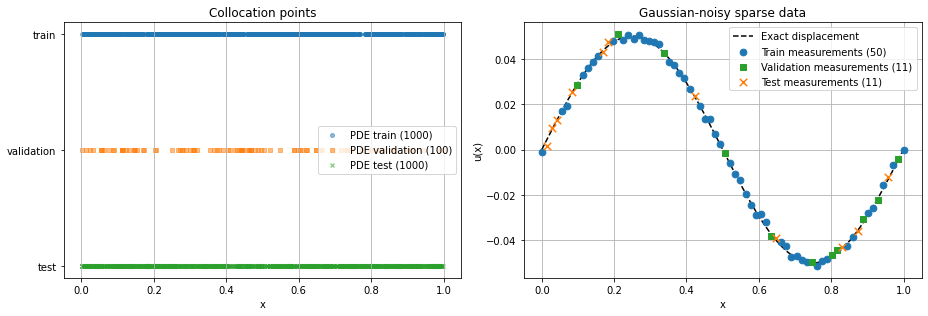

In [71]:
plot_points_and_data()

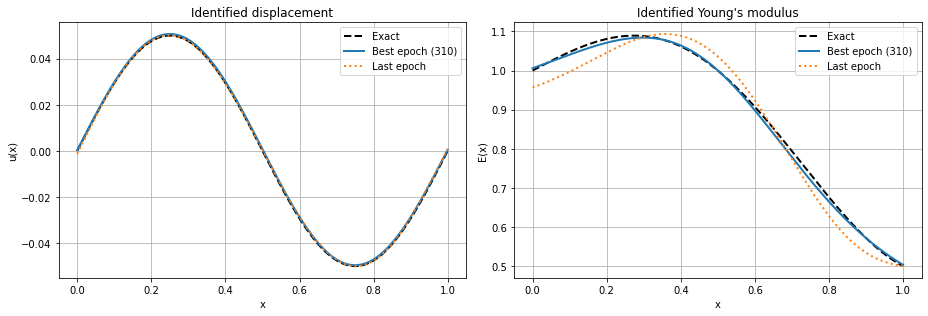

In [72]:
plot_identified_fields()

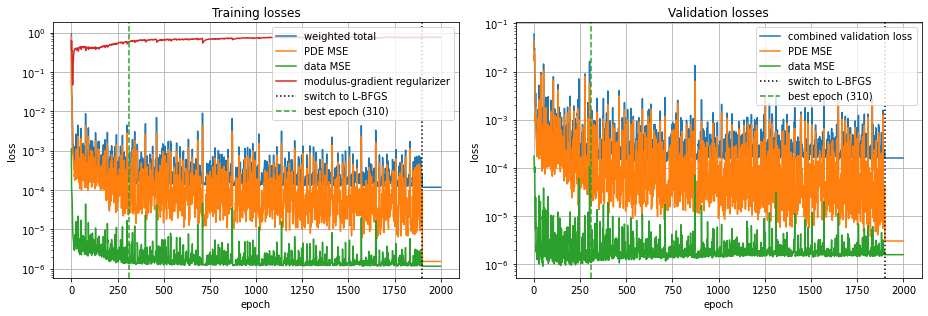

In [73]:
plot_losses()

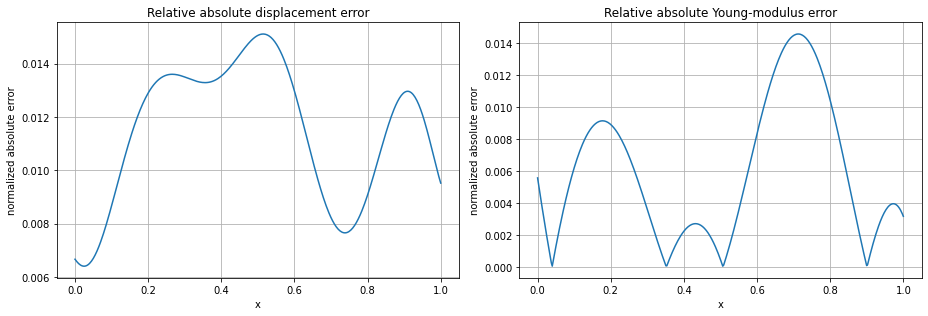

In [74]:
plot_absolute_errors()

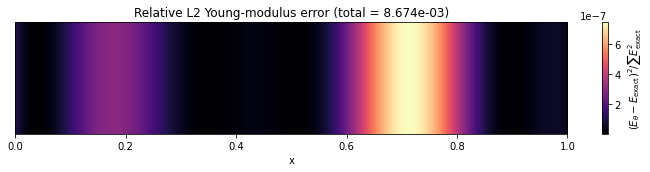

In [75]:
plot_modulus_l2_error_heatmap()